# 📦 JSON ETL, Analysis & Visualization
This notebook demonstrates how to:
- Read JSON content
- Read JSON file
- Perform ETL (Extract → Transform → Load)
- Analyze data
- Visualize results

A real-world scenario using **Customer Orders + Customer Profiles**.

# 📘 1. Sample JSON Data
We create two JSON datasets:

### **orders.json**
Customer orders.

### **customers.json**
Customer profile lookup.

In [1]:
import json
import pandas as pd

# --- JSON Content: Orders ---
orders_json = [
    {"order_id": 1, "customer_id": 1001, "amount": 120.50, "date": "2024-01-01"},
    {"order_id": 2, "customer_id": 1002, "amount": 75.00, "date": "2024-01-01"},
    {"order_id": 3, "customer_id": 1003, "amount": 200.00, "date": "2024-01-02"},
    {"order_id": 4, "customer_id": 1001, "amount": 50.00, "date": "2024-01-03"},
    {"order_id": 5, "customer_id": 1004, "amount": 300.00, "date": "2024-01-03"}
]

# --- JSON Content: Customers ---
customers_json = [
    {"customer_id": 1001, "name": "Alice", "city": "New York"},
    {"customer_id": 1002, "name": "Bob", "city": "Chicago"},
    {"customer_id": 1003, "name": "Charlie", "city": "Houston"},
    {"customer_id": 1004, "name": "David", "city": "Los Angeles"}
]

# Write JSON files
with open("orders.json", "w") as f:
    json.dump(orders_json, f, indent=4)

with open("customers.json", "w") as f:
    json.dump(customers_json, f, indent=4)

# 📘 2. Read JSON Content (Direct)

In [2]:
orders_df = pd.DataFrame(orders_json)
customers_df = pd.DataFrame(customers_json)

orders_df, customers_df

(   order_id  customer_id  amount        date
 0         1         1001   120.5  2024-01-01
 1         2         1002    75.0  2024-01-01
 2         3         1003   200.0  2024-01-02
 3         4         1001    50.0  2024-01-03
 4         5         1004   300.0  2024-01-03,
    customer_id     name         city
 0         1001    Alice     New York
 1         1002      Bob      Chicago
 2         1003  Charlie      Houston
 3         1004    David  Los Angeles)

# 📘 3. Read JSON File

In [3]:
orders_file_df = pd.read_json("orders.json")
customers_file_df = pd.read_json("customers.json")

orders_file_df, customers_file_df

(   order_id  customer_id  amount       date
 0         1         1001   120.5 2024-01-01
 1         2         1002    75.0 2024-01-01
 2         3         1003   200.0 2024-01-02
 3         4         1001    50.0 2024-01-03
 4         5         1004   300.0 2024-01-03,
    customer_id     name         city
 0         1001    Alice     New York
 1         1002      Bob      Chicago
 2         1003  Charlie      Houston
 3         1004    David  Los Angeles)

# 📘 4. ETL — Transform & Enrich Data
Steps:
- Convert date to datetime
- Join orders with customer profiles
- Sort by date
- Add calculated column: `amount_with_tax`

In [4]:
# Convert date
orders_df['date'] = pd.to_datetime(orders_df['date'])

# Join
merged_df = orders_df.merge(customers_df, on='customer_id', how='left')

# Add tax column
merged_df['amount_with_tax'] = merged_df['amount'] * 1.07

# Sort
merged_df = merged_df.sort_values(by='date')

merged_df

,order_id,customer_id,amount,date,name,city,amount_with_tax
0,1,1001,120.5,2024-01-01,Alice,New York,128.935
1,2,1002,75.0,2024-01-01,Bob,Chicago,80.250
2,3,1003,200.0,2024-01-02,Charlie,Houston,214.000
3,4,1001,50.0,2024-01-03,Alice,New York,53.500
4,5,1004,300.0,2024-01-03,David,Los Angeles,321.000


# 📘 5. Load — Write Output CSV

In [5]:
merged_df.to_csv("orders_etl_output.csv", index=False)
merged_df

,order_id,customer_id,amount,date,name,city,amount_with_tax
0,1,1001,120.5,2024-01-01,Alice,New York,128.935
1,2,1002,75.0,2024-01-01,Bob,Chicago,80.250
2,3,1003,200.0,2024-01-02,Charlie,Houston,214.000
3,4,1001,50.0,2024-01-03,Alice,New York,53.500
4,5,1004,300.0,2024-01-03,David,Los Angeles,321.000


# 📊 6. Analysis
We compute:
- Total revenue
- Revenue by city
- Daily revenue

In [6]:
total_revenue = merged_df['amount'].sum()
revenue_by_city = merged_df.groupby('city')['amount'].sum()
daily_revenue = merged_df.groupby('date')['amount'].sum()

total_revenue, revenue_by_city, daily_revenue

(745.5,
 city
 Chicago         75.0
 Houston        200.0
 Los Angeles    300.0
 New York       170.5
 Name: amount, dtype: float64,
 date
 2024-01-01    195.5
 2024-01-02    200.0
 2024-01-03    350.0
 Name: amount, dtype: float64)

# 📈 7. Visualization — Matplotlib & Seaborn

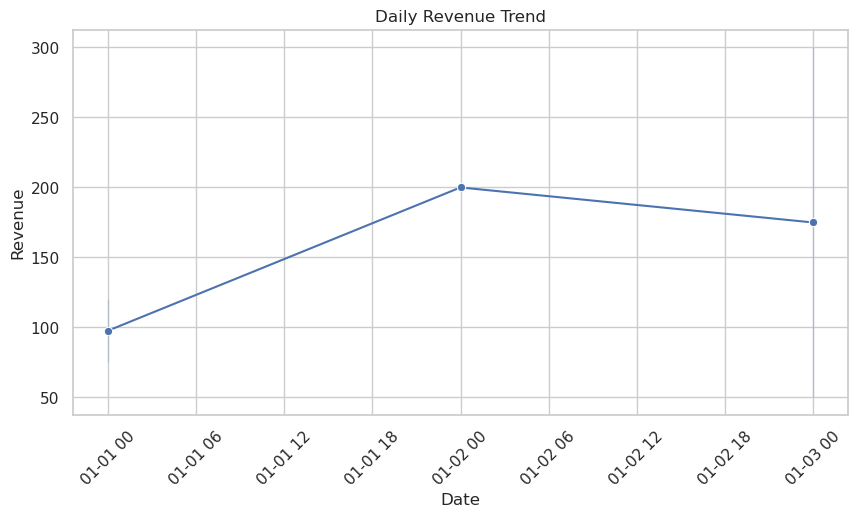

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Daily Revenue Trend
plt.figure(figsize=(10,5))
sns.lineplot(x=merged_df['date'], y=merged_df['amount'], marker='o')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

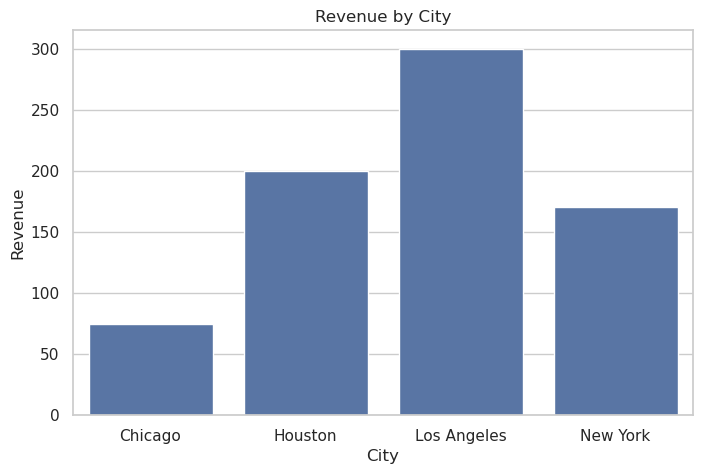

In [8]:
# Revenue by City
plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values)
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

## Complete !